In [1]:
import zipfile
# YOLOv8 kütüphanesini kur
!pip install ultralytics -q

import os
import glob
import shutil
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import yaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
with zipfile.ZipFile('/content/archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

In [3]:
annotations_path = 'data/annotations'
images_path = 'data/images'

In [4]:
print("/content/data/annotations/00000.xml")

/content/data/annotations/00000.xml


In [5]:
import os
import glob
import xml.etree.ElementTree as ET

# XML dosyalarının bulunduğu klasör (Önceki mesajdaki yol)
xml_folder = '/content/data/annotations'

# Klasördeki tüm .xml dosyalarını listele
xml_files = glob.glob(os.path.join(xml_folder, '*.xml'))

if len(xml_files) > 0:
    # 1. ÖRNEK BİR DOSYAYI YAZDIR
    sample_file = xml_files[1] # İlk dosyayı al
    print(f"--- Örnek Dosya İçeriği: {os.path.basename(sample_file)} ---")
    with open(sample_file, 'r') as f:
        print(f.read())

    print("\n" + "="*40 + "\n")

    # 2. TÜM SINIF İSİMLERİNİ OTOMATİK BUL (Eğitim için gerekli!)
    class_names = set() # Tekrar etmeyen küme

    print("Sınıf isimleri taranıyor...")
    for file in xml_files:
        try:
            tree = ET.parse(file)
            root = tree.getroot()
            # Her 'object' etiketi içindeki 'name' değerini al
            for obj in root.iter('object'):
                name = obj.find('name').text
                class_names.add(name)
        except Exception as e:
            print(f"Hata: {file} okunamadı. Sebebi: {e}")

    # Listeye çevirip sırala
    sorted_classes = sorted(list(class_names))

    print(f"Toplam {len(xml_files)} XML dosyası tarandı.")
    print("Bulunan Sınıflar :")
    print(f"classes = {sorted_classes}")

else:
    print(f"Hata: '{xml_folder}' konumunda hiç .xml dosyası bulunamadı. Yolu kontrol edin.")

--- Örnek Dosya İçeriği: 01598.xml ---
<annotation>
    <folder>images</folder>
    <filename>01598.jpg</filename>
    <path>images/01598.jpg</path>
    <source>
        <database>Unknown</database>
    </source>
    <size>
        <width>300</width>
        <height>300</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>brick_2x4</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <difficult>0</difficult>
        <bndbox>
            <xmin>225</xmin>
            <ymin>0</ymin>
            <xmax>281</xmax>
            <ymax>77</ymax>
        </bndbox>
    </object>    <object>
        <name>plate_2x4</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <difficult>0</difficult>
        <bndbox>
            <xmin>67</xmin>
            <ymin>39</ymin>
            <xmax>110</xmax>
            <ymax>84</ymax>
        </bndbox>
    </object>    <object>
        <name>plate_2x4</name>
  

In [6]:
# --- AYARLAR ---
# Verinin şu anki yolu (Drive veya Colab içindeki yol)
base_path = '/content/data' # Kendi yolunuza göre güncelleyin
images_source = os.path.join(base_path, 'images')
xml_source = os.path.join(base_path, 'annotations')

# Modelin eğitileceği yeni hedef klasör
dataset_path = '/content/yolo_dataset'

classes = ['brick_1x6', 'brick_2x2', 'brick_2x4', 'plate_1x2', 'plate_2x2', 'plate_2x4']

# --- DÖNÜŞÜM FONKSİYONU ---
def convert_to_yolo_format(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return (x, y, w, h)

def convert_annotation(xml_file, output_path):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    size = root.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    with open(output_path, 'w') as out_file:
        for obj in root.iter('object'):
            difficult = obj.find('difficult').text
            cls = obj.find('name').text
            if cls not in classes or int(difficult) == 1:
                continue
            cls_id = classes.index(cls)
            xmlbox = obj.find('bndbox')
            b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                 float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
            bb = convert_to_yolo_format((w, h), b)
            out_file.write(str(cls_id) + " " + " ".join([str(a) for a in bb]) + '\n')

# --- İŞLEMİ BAŞLAT ---
# Klasörleri oluştur
for set_name in ['train', 'val']:
    os.makedirs(os.path.join(dataset_path, 'images', set_name), exist_ok=True)
    os.makedirs(os.path.join(dataset_path, 'labels', set_name), exist_ok=True)

# Resimleri bul
all_images = glob.glob(os.path.join(images_source, '*.jpg')) + \
             glob.glob(os.path.join(images_source, '*.png')) + \
             glob.glob(os.path.join(images_source, '*.jpeg'))

# Train/Val ayır
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

def process_files(files, split_type):
    for img_path in files:
        filename = os.path.basename(img_path)
        name_only = os.path.splitext(filename)[0]

        # 1. Resmi Kopyala
        shutil.copy(img_path, os.path.join(dataset_path, 'images', split_type, filename))

        # 2. XML'i Bul ve Convert Et
        xml_file = os.path.join(xml_source, name_only + '.xml')
        if os.path.exists(xml_file):
            txt_output = os.path.join(dataset_path, 'labels', split_type, name_only + '.txt')
            convert_annotation(xml_file, txt_output)
        else:
            print(f"Uyarı: {filename} için XML bulunamadı.")

print("Dönüşüm ve taşıma işlemi başlıyor...")
process_files(train_imgs, 'train')
process_files(val_imgs, 'val')
print(f"İşlem tamamlandı! Veri seti burada: {dataset_path}")

Dönüşüm ve taşıma işlemi başlıyor...
İşlem tamamlandı! Veri seti burada: /content/yolo_dataset


In [7]:
data_yaml = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: name for i, name in enumerate(classes)},
    'nc': len(classes)
}

with open(f'{dataset_path}/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml dosyası hazır.")

data.yaml dosyası hazır.


In [8]:
# Modeli yükle (yolov8n.pt en hızlı olanıdır, daha yüksek başarı için yolov8s.pt veya yolov8m.pt deneyebilirsiniz)
model = YOLO('yolov8n.pt')

# Eğitimi başlat
results = model.train(
    data=f'{dataset_path}/data.yaml',
    epochs=50,       # Dönem sayısı
    imgsz=640,       # Resim boyutu
    batch=16,        # Batch size (RAM yetmezse 8 yapın)
    name='ozel_modelim'
)

Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=ozel_modelim, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

Test edilen resim: /content/yolo_dataset/images/val/01932.jpg

image 1/1 /content/yolo_dataset/images/val/01932.jpg: 640x640 1 brick_2x2, 1 plate_2x4, 7.3ms
Speed: 2.1ms preprocess, 7.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict5


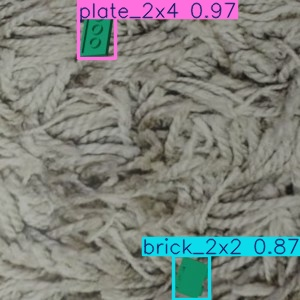

In [17]:
from ultralytics import YOLO
from IPython.display import Image, display

# 1. En iyi modeli yükle
model = YOLO('/content/runs/detect/ozel_modelim/weights/best.pt')

# 2. Test etmek istediğiniz bir resmin yolunu verin
# (Buraya test klasöründen rastgele bir resim yolu yazın veya yeni bir resim yükleyin)
test_image_path = '/content/yolo_dataset/images/val/buraya_dosya_adi_yazin.jpg'

# Eğer elinizde dosya adı yoksa rastgele bir tane seçelim:
import glob
import random
test_files = glob.glob('/content/yolo_dataset/images/val/*.jpg')
if test_files:
    test_image_path = random.choice(test_files)

print(f"Test edilen resim: {test_image_path}")

# 3. Tahmin yap
results = model.predict(source=test_image_path, save=True, conf=0.5) # %50 üzerindeki ihtimalleri çiz

# 4. Sonucu göster
for result in results:
    # Sonucun kaydedildiği klasörden resmi bulup gösterelim
    save_dir = result.save_dir
    img_name = os.path.basename(test_image_path)
    display(Image(filename=f"{save_dir}/{img_name}"))

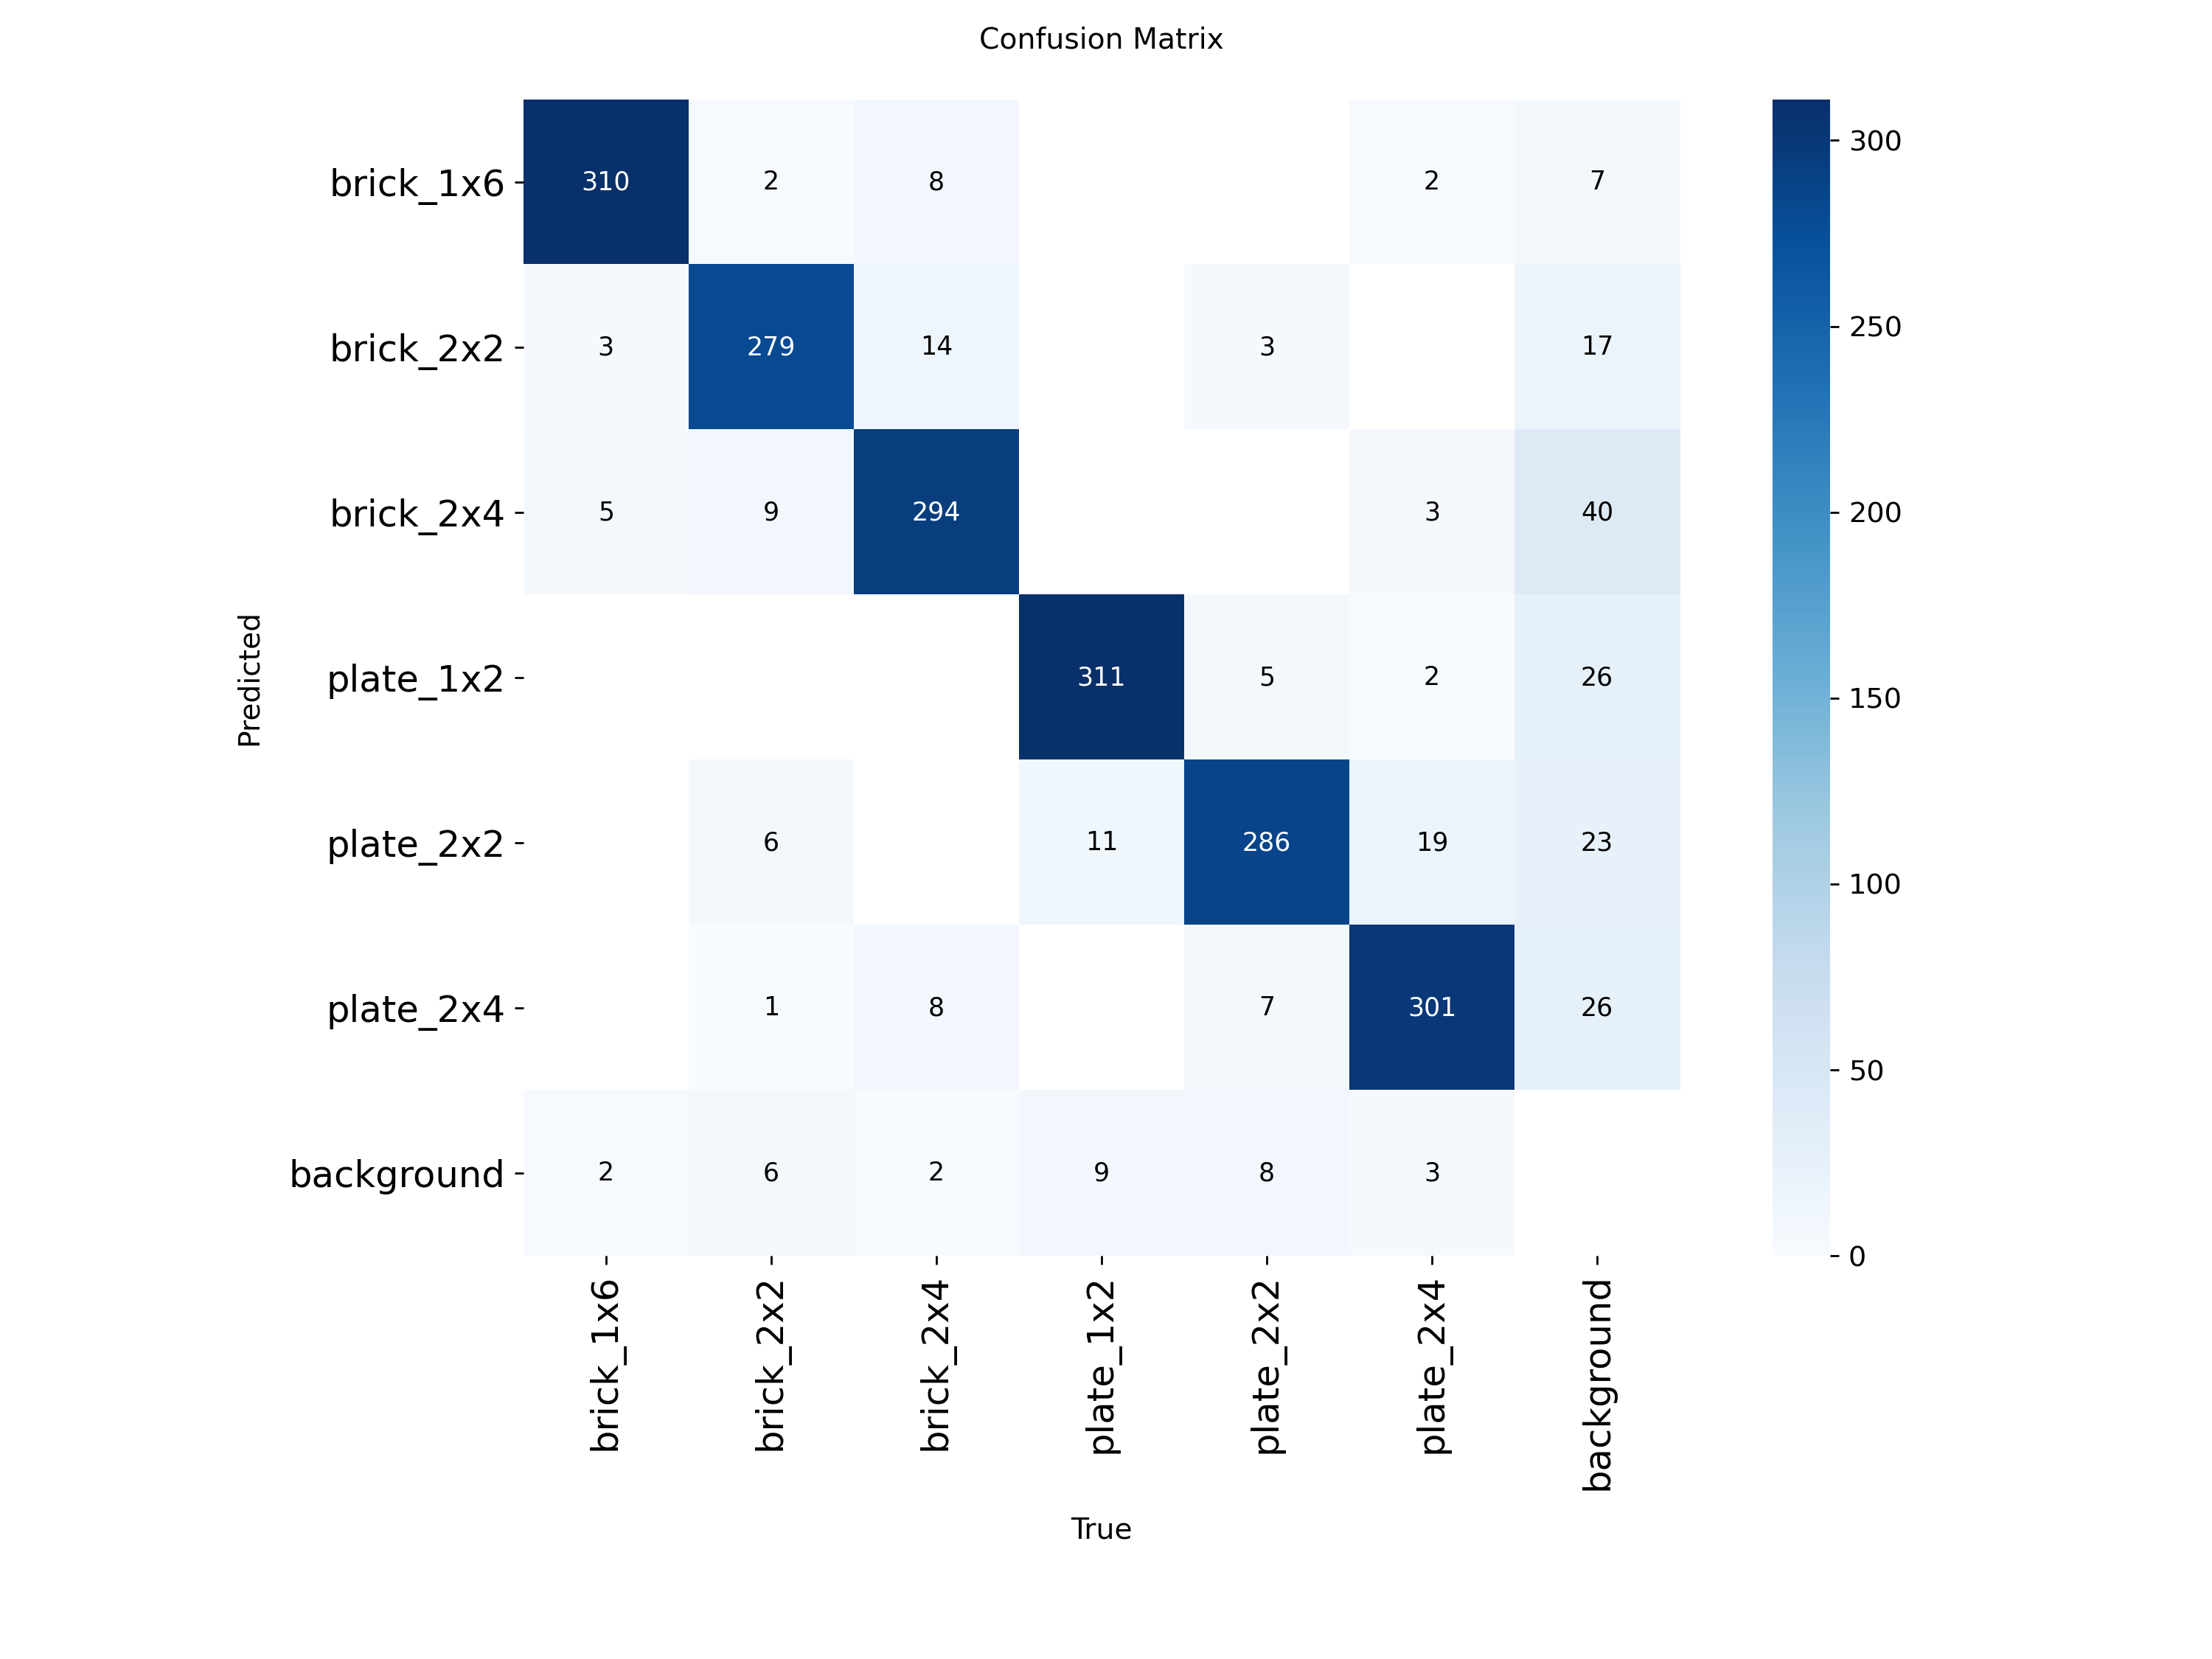

In [13]:
display(Image(filename='/content/runs/detect/ozel_modelim/confusion_matrix.png'))